# Interpreting Hydrometeorological Ensemble Verification Results

This notebook is the second part of the Hydrometeorological ensemble verification tutorial.

In the first notebook, we ran the `veriflow` pipeline and explored the returned `OutputDataset`.  
Here, we focus on **interpreting verification results**.

The goal is to understand what verification metrics and statistical criteria tell us about forecast performance, uncertainty, and reliability.

We will focus on three criteria:

- **Scatter plots**: how close forecasts are to observations
- **Continuous Ranked Probability Score (CRPS)**: probabilistic forecast quiality
- **Rank histograms**: ensemble reliability and spread

The example focuses on discharge (`Q`) forecasts for the River Rhine at **Lobith**.

## 1. What are we trying to evaluate?

Forecast verification can answer different questions depending on the criteria used.

In this notebook, we focus on:

- **Accuracy**: are forecasts close to the observed values?
- **Bias**: do forecasts systematically overestimate or underestimate discharge?
- **Lead-time behaviour**: how does forecast quality change from short to longer lead times?
- **Uncertainty**: does the ensemble spread represent the range of possible outcomes?
- **Reliability**: do observations behave as if they could plausibly come from the forecast ensemble?

These aspects are complementary. A forecast can be accurate on average but still poorly represent uncertainty, or it can have a realistic spread but still be biased.

## 2. Setup

We reuse the same case study and data sources as in Notebook 1.

The pipeline is run again here so that this notebook is self-contained.

In [1]:
# Add automatic reloading of modules in case of changes
%load_ext autoreload
%autoreload 2

from datetime import datetime, timezone
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from veriflow.configuration import Config, GeneralInfoConfig
from veriflow.configuration.utils import (
    LeadTimes,
    Range,
    TimeUnits,
    VerificationPair,
    VerificationPeriod,
)
from veriflow.constants import DataType
from veriflow.datasources import ZarrConfig
from veriflow.pipeline import run_pipeline
from veriflow.scores import CrpsForEnsembleConfig, RankHistogramConfig

## 3. Define and run the verification pipeline

The configuration below defines:

- the verification period
- the forecast datasets and observation dataset
- the lead times
- the verification metrics and diagnostic statistics

The discharge forecasts were generated by forcing the HBV hydrological model with raw or post-processed ECMWF meteorological ensemble reforecasts.

In [2]:
general = GeneralInfoConfig(
    verification_period=VerificationPeriod(
        start=datetime(1988, 1, 1, tzinfo=timezone.utc),
        end=datetime(2008, 12, 31, tzinfo=timezone.utc),
        dimension="forecast_reference_time",
    ),
    verification_pairs=[
        VerificationPair(id="raw_raw", obs="obs", sim="raw_raw", variable="Q"),
        VerificationPair(id="lin_log", obs="obs", sim="lin_log", variable="Q"),
        VerificationPair(id="qqt_qqt", obs="obs", sim="qqt_qqt", variable="Q"),
    ],
    lead_times=LeadTimes(
        unit=TimeUnits.day,
        values=Range(start=0, end=10, step=1),
    ),
)

In [10]:
datasources = [
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="obs",
        data_type=DataType.observed_historical,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/obs_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="raw_raw",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-raw-raw_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="lin_log",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-lin-log_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="qqt_qqt",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-qqt-qqt_Q.zarr",
    ),
]

In [11]:
scores = [
    CrpsForEnsembleConfig(
        score_adapter="crps_for_ensemble",
        general=general,
        reduce_dims=[],
    ),
    RankHistogramConfig(
        score_adapter="rank_histogram",
        general=general,
        reduce_dims=["forecast_reference_time"],
    ),
]

config = Config(
    fileversion="0.1.0",
    general=general,
    datasources=datasources,
    scores=scores,
)

In [12]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    handlers=[logging.StreamHandler()],
)

output_dataset = run_pipeline(config)

2026-06-02 11:32:22,183 INFO veriflow.pipeline: Successfully initialized the configuration. 
	 verification_period_start = 1988-01-01 00:00:00 
	 verification_period_end = 2008-12-31 00:00:00
2026-06-02 11:32:22,184 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-02 11:32:22,885 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-02 11:32:22,886 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-02 11:32:22,955 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-02 11:32:22,956 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-02 11:32:23,005 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-02 11:32:23,007 INFO veriflow.pipeline: Start getting data from Zarr.
2026-06-02 11:32:23,039 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-06-02 11:32:23,057 INFO veriflow.pipeline: Successfully loaded all data from sources.
2026-06-02 11:32:24,152 INFO veriflow.pipeline: Successfully computed CrpsForEnse

## 4. Prepare data for interpretation

The `OutputDataset` stores results per verification pair.  
We create a few helper objects and functions to make plotting easier.

In [13]:
verification_pairs = {pair.id: pair for pair in output_dataset.verification_pairs}
pair_datasets = {
    pair_id: output_dataset.get(verification_pair=pair)
    for pair_id, pair in verification_pairs.items()
}

forecast_variants = ["raw_raw", "lin_log", "qqt_qqt"]

# Use Lobith as the example station.
sample_ds = pair_datasets["raw_raw"]
example_station = str(sample_ds.station.values[0])
example_station

'H-RN-0001'

In [14]:
def get_lead_coord_name(obj):
    """Return the lead-time coordinate/dimension name used by an xarray object."""
    for name in ["lead_time", "forecast_period"]:
        if name in obj.dims or name in obj.coords:
            return name
    raise KeyError("No lead-time coordinate found. Expected 'lead_time' or 'forecast_period'.")


def select_lead_time(da, lead_days):
    """Select a lead time in days, robust to coordinate naming and dtype."""
    lead_name = get_lead_coord_name(da)
    target = np.timedelta64(lead_days, "D")

    try:
        return da.sel({lead_name: target})
    except Exception:
        try:
            return da.sel({lead_name: lead_days})
        except Exception:
            lead_values = da[lead_name].values
            if np.issubdtype(lead_values.dtype, np.timedelta64):
                lead_values_days = lead_values / np.timedelta64(1, "D")
            else:
                lead_values_days = lead_values
            idx = int(np.where(lead_values_days == lead_days)[0][0])
            return da.isel({lead_name: idx})


def use_valid_time_axis(da):
    """Use valid time as the plotting dimension when available."""
    if "forecast_reference_time" in da.dims and "time" in da.coords:
        return da.swap_dims({"forecast_reference_time": "time"})
    return da


def get_forecast_data(pair_id):
    """Return the forecast DataArray for one verification pair."""
    pair = verification_pairs[pair_id]
    pair_ds = pair_datasets[pair_id]
    if pair.sim in pair_ds.data_vars:
        return pair_ds[pair.sim]
    if pair_id in pair_ds.data_vars:
        return pair_ds[pair_id]
    raise KeyError(f"Could not find forecast variable for pair '{pair_id}'.")

## 5. Questions before interpreting the results

Before looking at the plots, consider the following questions.

1. What do you expect to happen to forecast skill as lead time increases?
2. Should a good ensemble forecast always have a very small spread?
3. Why might high-flow/flooding events be harder to forecast than normal-flow conditions?
4. Which criteria helps assess probabilistic accuracy?
5. Which diagnostic helps assess ensemble spread and reliability?

<details>
<summary>Show suggested answers</summary>

1. Forecast skill usually decreases as lead time increases because uncertainty grows further into the future.
2. No. A good ensemble should have an appropriate spread. If the spread is too small, observations may often fall outside the ensemble range.
3. High-flow/flooding events are often driven by complex rainfall, snowmelt, catchment storage, and routing processes. Small timing or precipitation errors can produce large discharge errors.
4. CRPS.
5. Rank histogram.

</details>

## 6. Scatter plots: observed versus forecast discharge

Scatter plots compare forecasted discharge against observed discharge.

- Points close to the **1:1 line** indicate good agreement.
- Points below the line indicate underestimation.
- Points above the line indicate overestimation.
- Increasing spread around the line indicates increasing forecast uncertainty or error.

Here we compare ensemble-mean forecasts with observations for lead times of 1, 5, and 10 days.

<span style="color: red;">[Jan's commect: why MEAN? why not simply show all ensemble members? -> Mo: possible of course, but not sure how intepretatble the figures of 6 plots wpuld be,
 -? Jurian, what do you think?]</span>. 

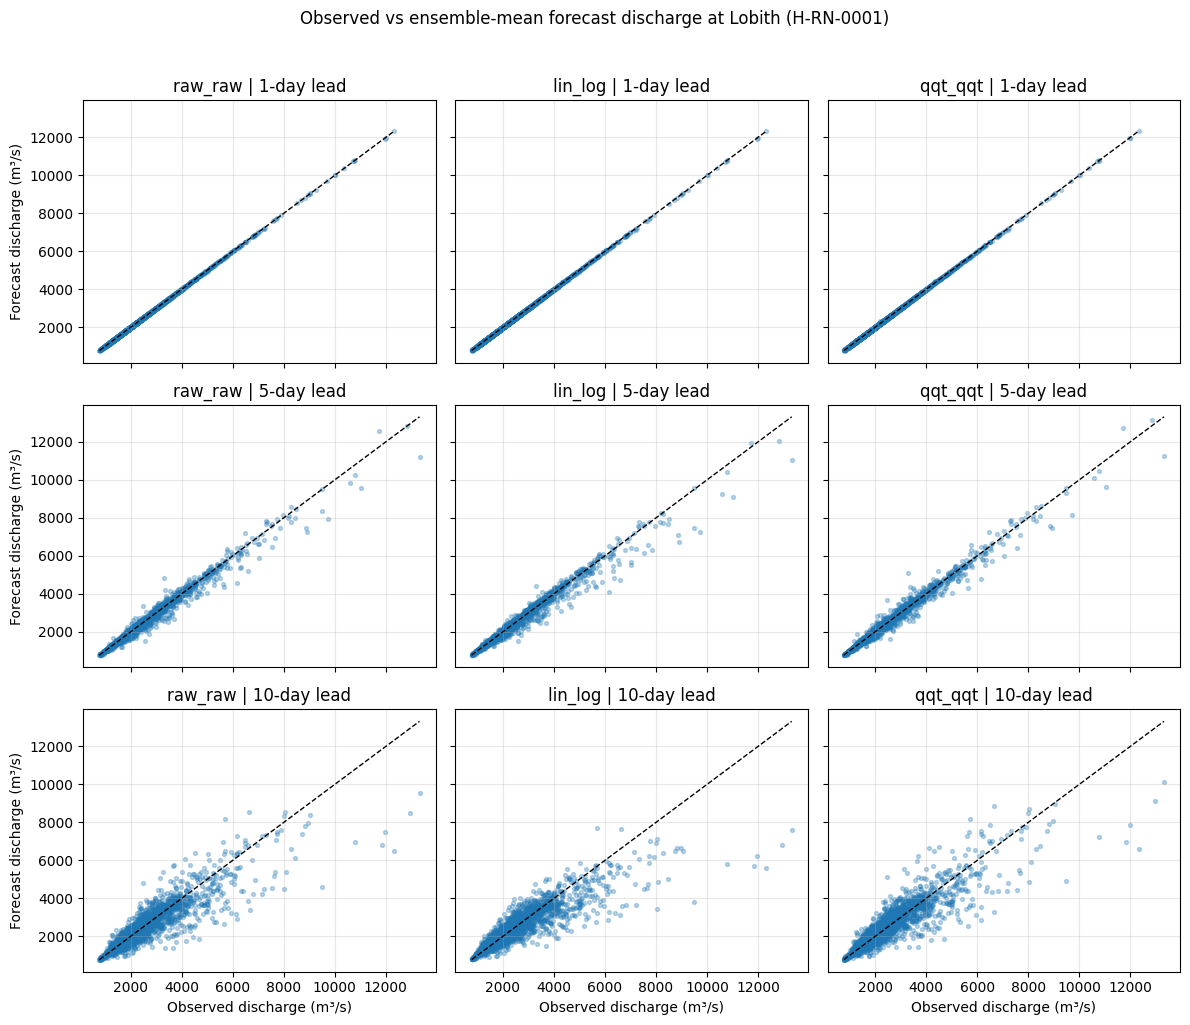

In [15]:
selected_leads = [1, 5, 10]

fig, axes = plt.subplots(
    len(selected_leads),
    len(forecast_variants),
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

axes = np.atleast_2d(axes)

for row, lead_day in enumerate(selected_leads):
    for col, pair_id in enumerate(forecast_variants):
        ds_variant = pair_datasets[pair_id]

        obs = ds_variant["obs"].sel(station=example_station)
        forecast = get_forecast_data(pair_id).sel(station=example_station)

        obs_lead = use_valid_time_axis(select_lead_time(obs, lead_day))
        forecast_lead = use_valid_time_axis(select_lead_time(forecast, lead_day))

        forecast_mean = forecast_lead.mean(dim="realization")

        valid = np.isfinite(obs_lead.values) & np.isfinite(forecast_mean.values)

        x = obs_lead.values[valid]
        y = forecast_mean.values[valid]

        ax = axes[row, col]
        ax.scatter(x, y, s=8, alpha=0.3)

        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="black",
            linestyle="--",
            linewidth=1,
        )

        ax.set_title(f"{pair_id} | {lead_day}-day lead")
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel("Forecast discharge (m³/s)")

        if row == len(selected_leads) - 1:
            ax.set_xlabel("Observed discharge (m³/s)")

plt.suptitle(
    f"Observed vs ensemble-mean forecast discharge at Lobith ({example_station})",
    y=1.02,
)

plt.tight_layout()
plt.show()

### Interpretation: scatter plots

At a **1-day lead time**, all forecast datasets show strong agreement with observations. The points lie close to the 1:1 line, indicating good short-range forecast accuracy.

At a **5-day lead time**, the spread around the 1:1 line increases. This indicates growing uncertainty and decreasing forecast skill. Some high observed discharge values are underestimated, especially during high-flow conditions.

At a **10-day lead time**, the relationship between forecasts and observations becomes weaker. The scatter increases further and high flows are more difficult to predict accurately.

Overall, the scatter plots show that forecast skill decreases with lead time and that forecast errors become larger for high discharge values.

## 7. Continuous Ranked Probability Score (CRPS)

CRPS measures how well an ensemble forecast matches the observed outcome. It evaluates the full forecast distribution, not just the ensemble mean.

- A CRPS of **0** indicates a perfect forecast.
- Lower values indicate better probabilistic forecast quality.
- CRPS increases when forecasts are biased or when the ensemble spread does not adequately represent the observation.

Here we compute the mean CRPS at Lobith as a function of lead time for each forecast dataset.

In [16]:
crps_by_variant = {}

for pair_id in forecast_variants:
    ds_variant = pair_datasets[pair_id]
    crps = ds_variant["crps_for_ensemble"].sel(station=example_station)

    # Average over forecast reference times to obtain CRPS by lead time.
    crps_mean = crps.mean(dim="forecast_reference_time", skipna=True)
    lead_name = get_lead_coord_name(crps_mean)

    lead_values = crps_mean[lead_name].values
    if np.issubdtype(lead_values.dtype, np.timedelta64):
        lead_days = (lead_values / np.timedelta64(1, "D")).astype(int)
    else:
        lead_days = lead_values

    crps_by_variant[pair_id] = pd.DataFrame(
        {
            "lead_time_days": lead_days,
            "crps": crps_mean.values,
            "forecast_dataset": pair_id,
        }
    )

crps_df = pd.concat(crps_by_variant.values(), ignore_index=True)
crps_df.head()

,lead_time_days,crps,forecast_dataset
0,1,1.500894,raw_raw
1,2,7.732856,raw_raw
2,3,20.205717,raw_raw
3,4,38.658575,raw_raw
4,5,62.932173,raw_raw


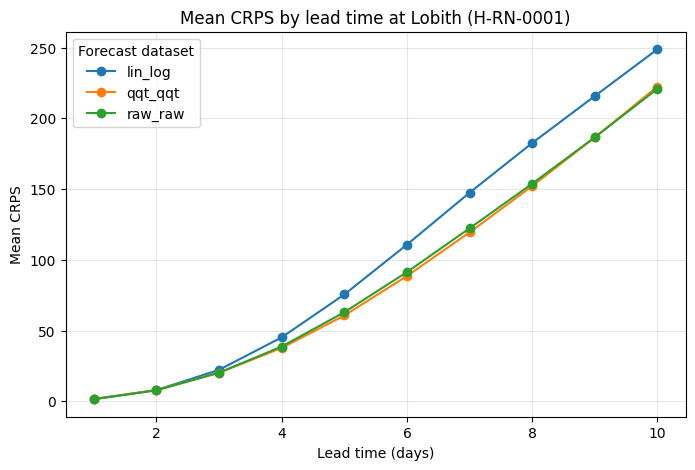

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for pair_id, group in crps_df.groupby("forecast_dataset"):
    ax.plot(
        group["lead_time_days"],
        group["crps"],
        marker="o",
        label=pair_id,
    )

ax.set_title(f"Mean CRPS by lead time at Lobith ({example_station})")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Mean CRPS")
ax.grid(True, alpha=0.3)
ax.legend(title="Forecast dataset")

plt.show()

### Interpretation: CRPS

The mean CRPS increases steadily with lead time for all forecast datasets. This indicates that probabilistic forecast skill decreases as predictions extend further into the future.

At **short lead times**, all forecast datasets have relatively low CRPS values, indicating good short-term probabilistic performance.

At **longer lead times**, the differences between datasets become clearer. Lower CRPS values indicate better probabilistic forecast quality. In this case, `raw_raw` and `qqt_qqt` remain closer to each other, while `lin_log` shows higher CRPS values at longer lead times.

Overall, the CRPS plot confirms the expected loss of skill with lead time and shows how different post-processing approaches affect probabilistic forecast performance.

## 8. Rank histograms

Rank histograms evaluate ensemble reliability and spread. They show where observations fall relative to the ordered ensemble members. For a well-calibrated ensemble, the histogram should be roughly uniform.

Common patterns:

- **U-shaped**: ensemble spread is too narrow; observations often fall outside the ensemble range.
- **Dome-shaped**: ensemble spread is too wide.
- **Skewed**: forecasts may be biased high or low.

Here we compare rank histograms for the three forecast datasets and selected lead times.

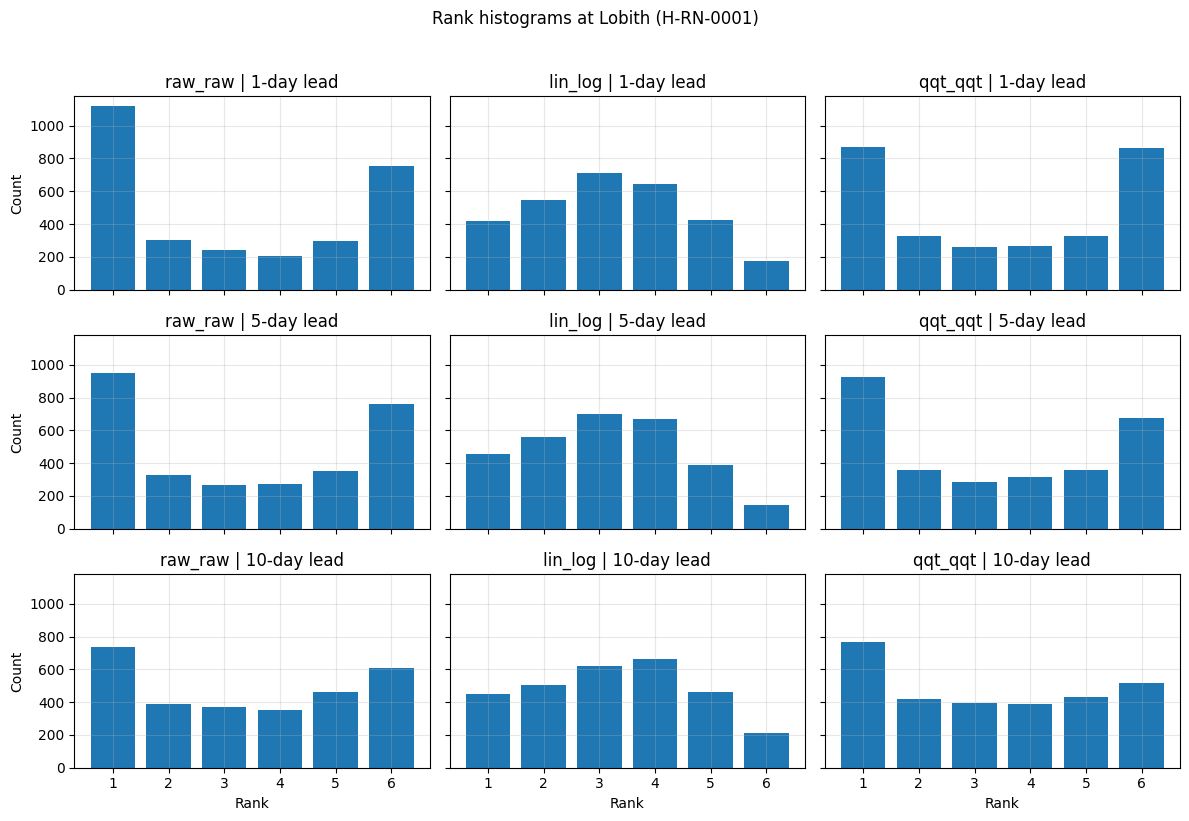

In [18]:
selected_leads = [1, 5, 10]

fig, axes = plt.subplots(
    len(selected_leads),
    len(forecast_variants),
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

axes = np.atleast_2d(axes)

for row, lead_day in enumerate(selected_leads):
    for col, pair_id in enumerate(forecast_variants):
        ds_variant = pair_datasets[pair_id]
        rank_hist = ds_variant["histogram_rank"].sel(station=example_station)
        hist = select_lead_time(rank_hist, lead_day)

        ax = axes[row, col]
        ax.bar(
            hist["rank"].values,
            hist.values.squeeze(),
            width=0.8,
        )

        ax.set_title(f"{pair_id} | {lead_day}-day lead")
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel("Count")

        if row == len(selected_leads) - 1:
            ax.set_xlabel("Rank")

plt.suptitle(f"Rank histograms at Lobith ({example_station})", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation: rank histograms

The rank histograms show clear differences between the forecast datasets.

The `raw_raw` forecasts show a pronounced **U-shaped** histogram, especially at short lead times. This indicates that observations often fall outside the ensemble range, suggesting that the raw ensemble is **underdispersed**.

The `lin_log` histograms are flatter than those of `raw_raw`, especially at longer lead times. This suggests improved representation of ensemble spread, although some asymmetry remains.

The `qqt_qqt` forecasts also reduce the strong U-shape seen in `raw_raw`. The histograms are still not perfectly uniform, but they suggest improved calibration compared with the raw ensemble.

Overall, the rank histograms show that post-processing can improve ensemble reliability, even when forecast accuracy still decreases with lead time.

## 9. Bringing the evaluations together

Each criteria tells us something different:

| Criteria | Main question | What we learned |
|---|---|---|
| Scatter plot | Are forecasts close to observations? | Alignment decreases with lead time, especially for high flows. |
| CRPS | How good is the full probabilistic forecast? | Probabilistic skill decreases with lead time. |
| Rank histogram | Is the ensemble spread reliable? | Raw forecasts are underdispersed; post-processing improves calibration. |

These criteria should be interpreted together. A forecast dataset may perform well according to one criteria but reveal weaknesses in another.

## 10. Reflection questions

1. Why does forecast skill usually decrease with lead time?
2. Can a forecast have low CRPS but still have a problematic rank histogram?
3. What does an underdispersed ensemble mean in practice?
4. Why use multiple criteria instead of one score?

<details>
<summary>Show suggested answers</summary>

1. FBecause uncertainty grows as forecasts extend further into the future. Errors in meteorological inputs, model states, and hydrological processes accumulate over time.
2. es. CRPS summarizes probabilistic quality, while the rank histogram specifically relfects ensemble reliability and spread. A forecast can have reasonable average accuracy but still be underdispersed.
3. The ensemble spread is too narrow. Observations fall outside the ensemble range more often than expected, meaning forecast uncertainty is underestimated.
4. Forecast quality has multiple aspects: accuracy, bias, uncertainty, reliability, and behaviour during extremes. No single diagnostic captures everything.

</details>

## 11. Summary

For the Lobith discharge forecasts:

- Forecast skill decreases with lead time.
- Forecast errors increase for high-flow events.
- CRPS confirms the loss of probabilistic forecast skill at longer lead times.
- Rank histograms show that the raw ensemble is underdispersed.
- Post-processing improves ensemble reliability, especially in terms of ensemble spread.

Together, these results show why ensemble forecast verification should combine multiple diagnostics rather than relying on a single plot or score.